In [1]:
import sys, os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from dataset.mnist import load_mnist
from deeper_conv_net import DeeperConvNet
from common.trainer import Trainer

In [4]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

In [5]:
max_epochs = 20

In [6]:
network = DeeperConvNet()

In [7]:
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer = 'Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)

In [8]:
trainer.train()

train loss:2.3091031135013025
=== epoch:1, train acc:0.192, test acc:0.168 ===
train loss:2.292771016949616
train loss:2.304086973482472
train loss:2.2907773945061543
train loss:2.2514470899683277
train loss:2.2778935641042413
train loss:2.261802499187267
train loss:2.2631986471281538
train loss:2.212929926853668
train loss:2.2268123241277094
train loss:2.1607654428982768
train loss:2.2299066478165996
train loss:2.1716125731925637
train loss:2.1692634468269394
train loss:2.127604162633296
train loss:2.2059087128642605
train loss:2.1132130508290303
train loss:2.1074227144808897
train loss:2.0389921343399333
train loss:2.070014497797077
train loss:1.9719405014370421
train loss:2.0300333559320225
train loss:2.0620234607004253
train loss:2.0213274387807725
train loss:1.9725081864042326
train loss:2.008053101803696
train loss:2.1050428285207765
train loss:1.9921201446272392
train loss:1.8651486985118677
train loss:2.079943288914341
train loss:1.8214742519772054
train loss:1.9635643771247693

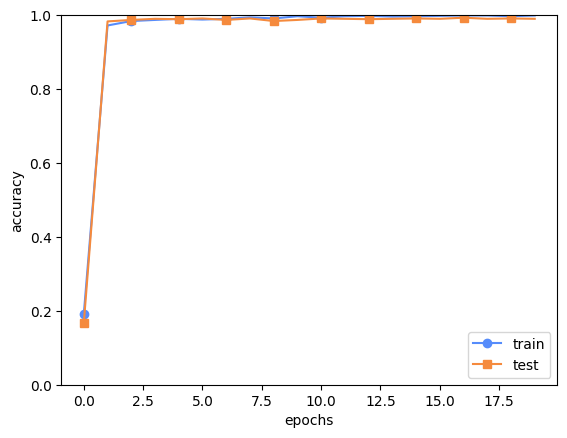

In [9]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [10]:
def filter_show(filters, nx=8, margin=3, scale=10):
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()

In [11]:
network.save_params("params.pkl")

In [12]:
network = DeeperConvNet()
# 무작위(랜덤) 초기화 후의 가중치
filter_show(network.params['W1'])

# 학습된 가중치
network.load_params("params.pkl")
filter_show(network.params['W1'])

NameError: name 'SimpleConvNet' is not defined